In [135]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [136]:
ends_df = pd.read_csv('./curling_database/ends.csv')
stones_df = pd.read_csv('./curling_database/stones.csv')
print(len(ends_df))
pp_active_rows = ends_df[ends_df['PowerPlay'] > 0].copy()
pp_game_ends = pp_active_rows[['CompetitionID', 'SessionID', 'GameID', 'EndID']].drop_duplicates()
pp_full_ends = pd.merge(ends_df, pp_game_ends, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
pp_full_ends

5274


,CompetitionID,SessionID,GameID,TeamID,EndID,Result,PowerPlay
0,0,1,1,19,6,0,NaN
1,0,1,1,27,6,1,1.0
2,0,1,1,19,7,0,1.0
3,0,1,1,27,7,3,NaN
4,0,1,2,20,6,0,NaN
...,...,...,...,...,...,...,...
1191,24250026,46,3,20,7,2,2.0
1192,24250026,48,1,37,6,0,2.0
1193,24250026,48,1,46,6,1,NaN
1194,24250026,49,1,14,6,3,2.0


In [137]:
stones_df

,CompetitionID,SessionID,GameID,EndID,ShotID,TeamID,PlayerID,Task,Handle,Points,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,1,7,19,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,1,8,27,1,0,1,2,...,892.0,1232.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,1,1,9,19,2,0,0,4,...,892.0,1232.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,1,1,16,27,2,0,0,0,...,892.0,1232.0,418.0,1608.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,1,1,17,19,2,7,0,3,...,4095.0,0.0,418.0,1608.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26365,24250026,49,1,7,18,24,2,9,0,4,...,901.0,470.0,787.0,2001.0,500.0,567.0,0.0,0.0,0.0,0.0
26366,24250026,49,1,7,19,14,2,0,0,3,...,901.0,470.0,787.0,2001.0,500.0,567.0,0.0,0.0,0.0,0.0
26367,24250026,49,1,7,20,24,2,6,0,4,...,901.0,470.0,787.0,2001.0,500.0,567.0,272.0,797.0,0.0,0.0
26368,24250026,49,1,7,21,14,1,0,0,4,...,901.0,470.0,787.0,2001.0,500.0,567.0,272.0,797.0,0.0,0.0


In [138]:
def analyze_pp_outcome(group):
    # Find the row with PowerPlay > 0
    attacker = group[group['PowerPlay'] > 0].iloc[0]
    
    # The score of the ATTACKING team
    attacker_score = attacker['Result']
    
    # Define Defense Quality
    if attacker_score == 0:
        return 'Steal (Best)'
    elif attacker_score == 1:
        return 'Force (Good)'
    else:
        return 'Failure (Bad)'

outcomes = pp_full_ends.groupby(['CompetitionID', 'SessionID', 'GameID', 'EndID']).apply(analyze_pp_outcome).reset_index(name='Defense_Outcome')

/var/folders/8q/pd8bhfh923x7_5hc541qy_8c0000gn/T/ipykernel_43701/860284094.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outcomes = pp_full_ends.groupby(['CompetitionID', 'SessionID', 'GameID', 'EndID']).apply(analyze_pp_outcome).reset_index(name='Defense_Outcome')


In [139]:
first_shots = stones_df[stones_df['ShotID'] == 7]
first_shots

,CompetitionID,SessionID,GameID,EndID,ShotID,TeamID,PlayerID,Task,Handle,Points,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,1,7,19,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0,1,1,2,7,27,1,0,0,4,...,712.0,727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0,1,1,3,7,19,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30,0,1,1,4,7,27,1,0,0,3,...,775.0,1100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,0,1,1,5,7,19,1,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26320,24250026,49,1,3,7,14,1,0,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26330,24250026,49,1,4,7,24,1,0,0,4,...,766.0,731.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26340,24250026,49,1,5,7,24,1,0,1,4,...,743.0,737.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26350,24250026,49,1,6,7,24,1,4,0,4,...,77.0,1838.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [140]:
first_shots = stones_df[stones_df['ShotID'] == 7]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])

In [141]:
analysis_df

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,6,Force (Good),7,19,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,7,Steal (Best),7,27,1,0,0,...,1098.0,921.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,2,6,Failure (Bad),7,20,1,4,0,...,433.0,2008.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,2,7,Failure (Bad),7,46,1,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,3,6,Failure (Bad),7,22,1,0,0,...,997.0,1897.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad),7,46,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594,24250026,46,3,6,Force (Good),7,20,1,4,0,...,4095.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
595,24250026,46,3,7,Failure (Bad),7,10,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
596,24250026,48,1,6,Steal (Best),7,46,1,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


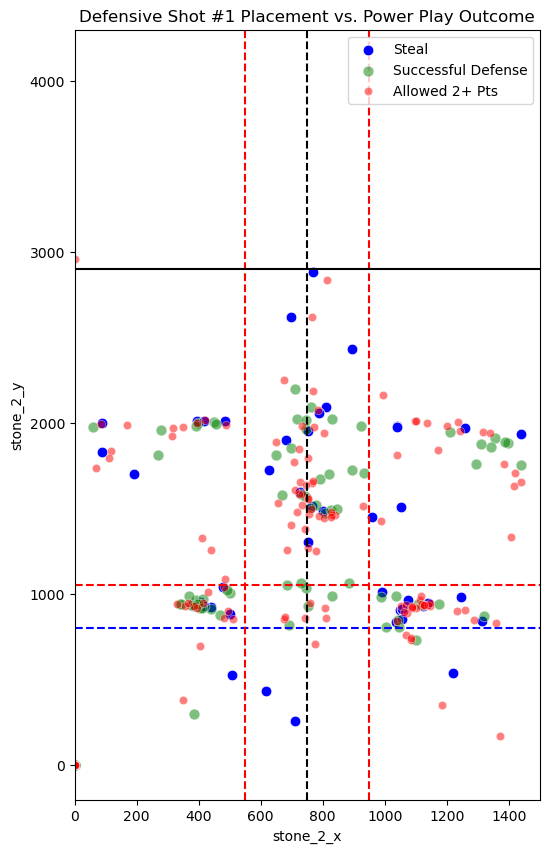

In [142]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', s=60, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', s=60, alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on your Y-axis data
plt.show()

In [143]:
curious_zones = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_2_y'] < 1050) & (analysis_df['stone_2_y'] > 750))]
success_rate = curious_zones['Defense_Outcome'].value_counts(normalize=True)
print(len(curious_zones))
success_rate

81


Defense_Outcome
Failure (Bad)    0.419753
Force (Good)     0.333333
Steal (Best)     0.246914
Name: proportion, dtype: float64

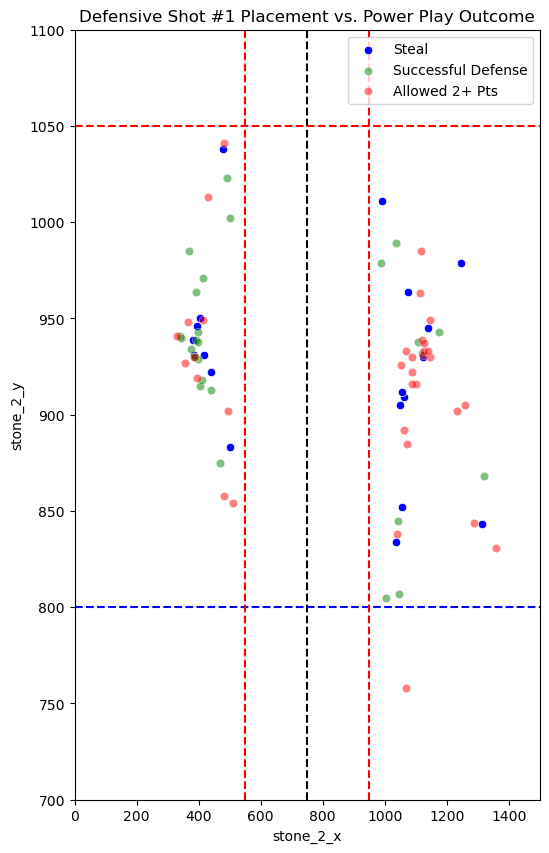

In [144]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=curious_zones[curious_zones['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=curious_zones[curious_zones['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=curious_zones[curious_zones['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.ylim(700, 1100)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on your Y-axis data
plt.show()

In [145]:
overall_rate = analysis_df['Defense_Outcome'].value_counts(normalize=True)
print(len(analysis_df))
overall_rate

598


Defense_Outcome
Failure (Bad)    0.468227
Force (Good)     0.326087
Steal (Best)     0.205686
Name: proportion, dtype: float64

In [146]:
center = analysis_df[((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950))]
center_rate = center['Defense_Outcome'].value_counts(normalize=True)
print(len(center))
center_rate

87


Defense_Outcome
Failure (Bad)    0.517241
Force (Good)     0.321839
Steal (Best)     0.160920
Name: proportion, dtype: float64

In [147]:
true_center = analysis_df[((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950) & (analysis_df['stone_2_y'] <= 1050) & (analysis_df['stone_2_y'] >= 750))]
true_center_rate = true_center['Defense_Outcome'].value_counts(normalize=True)
print(len(true_center))
true_center_rate

10


Defense_Outcome
Failure (Bad)    0.6
Force (Good)     0.4
Name: proportion, dtype: float64

In [148]:
high_center = analysis_df[((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950) & (analysis_df['stone_2_y'] > 1050))]
high_center_rate = high_center['Defense_Outcome'].value_counts(normalize=True)
print(len(high_center))
high_center_rate

74


Defense_Outcome
Failure (Bad)    0.513514
Force (Good)     0.324324
Steal (Best)     0.162162
Name: proportion, dtype: float64

In [149]:
outside = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950))]
outside_rate = outside['Defense_Outcome'].value_counts(normalize=True)
print(len(outside))
outside_rate

511


Defense_Outcome
Failure (Bad)    0.459883
Force (Good)     0.326810
Steal (Best)     0.213307
Name: proportion, dtype: float64

In [150]:
outside_guard = analysis_df[(analysis_df['stone_2_y'] > 1050) & ((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950))]
outside_guard_rate = outside_guard['Defense_Outcome'].value_counts(normalize=True)
print(len(outside_guard))
outside_guard_rate

83


Defense_Outcome
Failure (Bad)    0.518072
Force (Good)     0.265060
Steal (Best)     0.216867
Name: proportion, dtype: float64

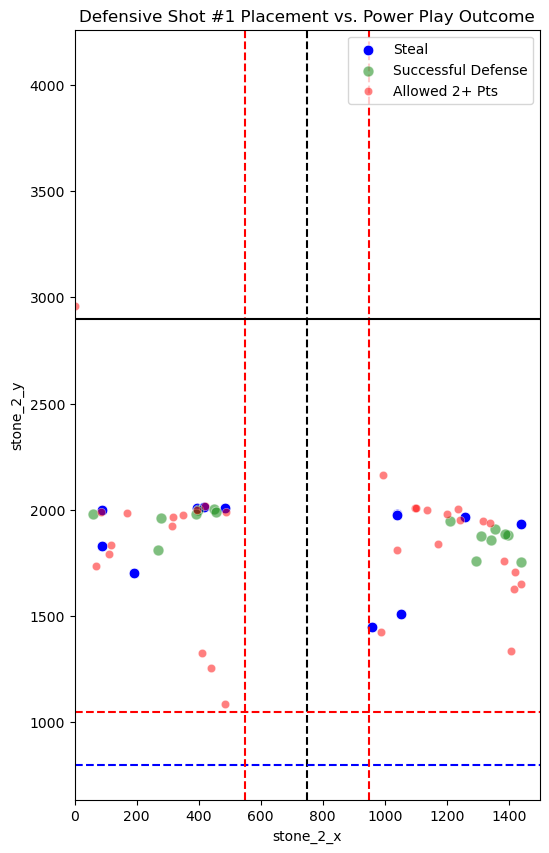

In [151]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=outside_guard[outside_guard['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', s=60, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=outside_guard[outside_guard['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', s=60, alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=outside_guard[outside_guard['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on your Y-axis data
plt.show()

In [152]:
first_shots = stones_df[stones_df['ShotID'] == 9]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])

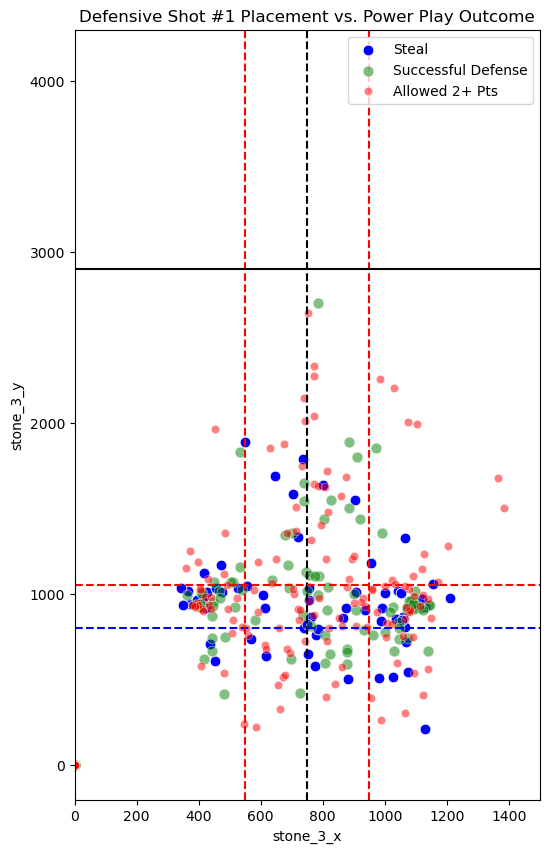

In [153]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_3_x', y='stone_3_y', color='blue', s=60, label='Steal'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_3_x', y='stone_3_y', color='green', s=60, alpha=0.5, label='Successful Defense'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_3_x', y='stone_3_y', color='red', alpha=0.5, label='Allowed 2+ Pts'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on your Y-axis data
plt.show()

In [154]:
overall_rate = analysis_df['Defense_Outcome'].value_counts(normalize=True)
print(len(analysis_df))
print(overall_rate)
curious_zones = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_2_y'] < 1050) & (analysis_df['stone_2_y'] > 750))]
success_rate = curious_zones['Defense_Outcome'].value_counts(normalize=True)
print(len(curious_zones))
print("outer central", success_rate)
center = analysis_df[((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950))]
center_rate = center['Defense_Outcome'].value_counts(normalize=True)
print(len(center))
print('center', center_rate)
outside = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950))]
outside_rate = outside['Defense_Outcome'].value_counts(normalize=True)
print(len(outside))
print('outside', outside_rate)

598
Defense_Outcome
Failure (Bad)    0.468227
Force (Good)     0.326087
Steal (Best)     0.205686
Name: proportion, dtype: float64
170
outer central Defense_Outcome
Failure (Bad)    0.458824
Force (Good)     0.323529
Steal (Best)     0.217647
Name: proportion, dtype: float64
130
center Defense_Outcome
Failure (Bad)    0.523077
Force (Good)     0.300000
Steal (Best)     0.176923
Name: proportion, dtype: float64
468
outside Defense_Outcome
Failure (Bad)    0.452991
Force (Good)     0.333333
Steal (Best)     0.213675
Name: proportion, dtype: float64


In [155]:
first_shots = stones_df[(stones_df['ShotID'] == 9)]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])

In [156]:
overall_rate = analysis_df['Defense_Outcome'].value_counts(normalize=True)
print(len(analysis_df))
print('overall rate', overall_rate)
double_center = analysis_df[((analysis_df['stone_2_x'] >= 550) & (analysis_df['stone_2_x'] <= 950) & (analysis_df['stone_3_x'] >= 550) & (analysis_df['stone_3_x'] <= 950))]
double_center_rate = double_center['Defense_Outcome'].value_counts(normalize=True)
print(len(double_center))
print('double center', double_center_rate)
out_in = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_3_x'] >= 550) & (analysis_df['stone_3_x'] <= 950))]
out_in_rate = out_in['Defense_Outcome'].value_counts(normalize=True)
print(len(out_in))
print('out in', out_in_rate)
double_out = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_3_x'] < 550) | (analysis_df['stone_3_x'] > 950))]
double_out_rate = double_out['Defense_Outcome'].value_counts(normalize=True)
print(len(double_out))
print('double out', double_out_rate)

598
overall rate Defense_Outcome
Failure (Bad)    0.468227
Force (Good)     0.326087
Steal (Best)     0.205686
Name: proportion, dtype: float64
50
double center Defense_Outcome
Failure (Bad)    0.56
Force (Good)     0.32
Steal (Best)     0.12
Name: proportion, dtype: float64
76
out in Defense_Outcome
Failure (Bad)    0.486842
Force (Good)     0.263158
Steal (Best)     0.250000
Name: proportion, dtype: float64
392
double out Defense_Outcome
Failure (Bad)    0.446429
Force (Good)     0.346939
Steal (Best)     0.206633
Name: proportion, dtype: float64


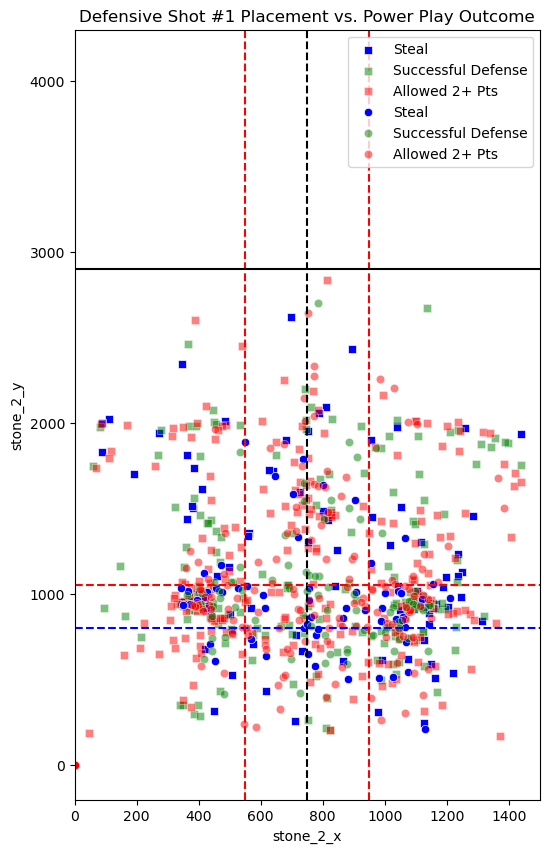

In [157]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_2_x', y='stone_2_y', color='blue', label='Steal', marker='s'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_2_x', y='stone_2_y', color='green', alpha=0.5, label='Successful Defense', marker='s'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_2_x', y='stone_2_y', color='red', alpha=0.5, label='Allowed 2+ Pts', marker='s'
)

sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome']== 'Steal (Best)'],
    x='stone_3_x', y='stone_3_y', color='blue', label='Steal', marker='o'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'].isin(['Force (Good)'])],
    x='stone_3_x', y='stone_3_y', color='green', alpha=0.5, label='Successful Defense', marker='o'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=analysis_df[analysis_df['Defense_Outcome'] == 'Failure (Bad)'],
    x='stone_3_x', y='stone_3_y', color='red', alpha=0.5, label='Allowed 2+ Pts', marker='o'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on your Y-axis data
plt.show()

In [158]:
ends_df = pd.read_csv('./curling_database/ends.csv')
stones_df = pd.read_csv('./curling_database/stones.csv')
print(len(ends_df))
pp_active_rows = ends_df[ends_df['PowerPlay'] > 0].copy()
pp_game_ends = pp_active_rows[['CompetitionID', 'SessionID', 'GameID', 'EndID']].drop_duplicates()
pp_full_ends = pd.merge(ends_df, pp_game_ends, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
pp_full_ends

5274


,CompetitionID,SessionID,GameID,TeamID,EndID,Result,PowerPlay
0,0,1,1,19,6,0,NaN
1,0,1,1,27,6,1,1.0
2,0,1,1,19,7,0,1.0
3,0,1,1,27,7,3,NaN
4,0,1,2,20,6,0,NaN
...,...,...,...,...,...,...,...
1191,24250026,46,3,20,7,2,2.0
1192,24250026,48,1,37,6,0,2.0
1193,24250026,48,1,46,6,1,NaN
1194,24250026,49,1,14,6,3,2.0


In [159]:
outcomes = pp_full_ends.groupby(['CompetitionID', 'SessionID', 'GameID', 'EndID']).apply(analyze_pp_outcome).reset_index(name='Defense_Outcome')

/var/folders/8q/pd8bhfh923x7_5hc541qy_8c0000gn/T/ipykernel_43701/2814170009.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outcomes = pp_full_ends.groupby(['CompetitionID', 'SessionID', 'GameID', 'EndID']).apply(analyze_pp_outcome).reset_index(name='Defense_Outcome')


In [160]:
outcomes

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome
0,0,1,1,6,Force (Good)
1,0,1,1,7,Steal (Best)
2,0,1,2,6,Failure (Bad)
3,0,1,2,7,Failure (Bad)
4,0,1,3,6,Failure (Bad)
...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad)
594,24250026,46,3,6,Force (Good)
595,24250026,46,3,7,Failure (Bad)
596,24250026,48,1,6,Steal (Best)


In [161]:
first_shots = stones_df[stones_df['ShotID'] == 7]
analysis_df = pd.merge(outcomes, first_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
analysis_df

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,6,Force (Good),7,19,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,7,Steal (Best),7,27,1,0,0,...,1098.0,921.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,2,6,Failure (Bad),7,20,1,4,0,...,433.0,2008.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,2,7,Failure (Bad),7,46,1,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,3,6,Failure (Bad),7,22,1,0,0,...,997.0,1897.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad),7,46,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594,24250026,46,3,6,Force (Good),7,20,1,4,0,...,4095.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
595,24250026,46,3,7,Failure (Bad),7,10,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
596,24250026,48,1,6,Steal (Best),7,46,1,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [162]:
curious_zones = analysis_df[((analysis_df['stone_2_x'] < 550) | (analysis_df['stone_2_x'] > 950)) & ((analysis_df['stone_2_y'] < 1050) & (analysis_df['stone_2_y'] > 750))]
curious_zones

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
5,0,1,3,7,Steal (Best),7,17,1,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,2,1,7,Failure (Bad),7,46,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22,0,4,3,6,Force (Good),7,43,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46,0,9,1,7,Failure (Bad),7,27,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55,0,10,2,6,Steal (Best),7,27,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,24250026,14,5,8,Failure (Bad),7,34,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
559,24250026,16,3,6,Failure (Bad),7,17,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
577,24250026,18,2,8,Failure (Bad),7,17,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
584,24250026,41,1,7,Steal (Best),7,37,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [163]:
second_shots = stones_df[stones_df['ShotID'] == 9]
temp_df = pd.merge(outcomes, second_shots, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
temp_df

,CompetitionID,SessionID,GameID,EndID,Defense_Outcome,ShotID,TeamID,PlayerID,Task,Handle,...,stone_8_x,stone_8_y,stone_9_x,stone_9_y,stone_10_x,stone_10_y,stone_11_x,stone_11_y,stone_12_x,stone_12_y
0,0,1,1,6,Force (Good),9,19,2,0,0,...,1101.0,529.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,1,7,Steal (Best),9,27,2,0,1,...,1098.0,921.0,652.0,794.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,2,6,Failure (Bad),9,20,2,0,0,...,433.0,2008.0,1046.0,759.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,1,2,7,Failure (Bad),9,46,2,0,1,...,1154.0,694.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,3,6,Failure (Bad),9,22,2,0,0,...,997.0,1897.0,923.0,1135.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,24250026,46,2,8,Failure (Bad),9,46,2,1,0,...,4095.0,4095.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
594,24250026,46,3,6,Force (Good),9,20,2,0,1,...,4095.0,0.0,405.0,932.0,0.0,0.0,0.0,0.0,0.0,0.0
595,24250026,46,3,7,Failure (Bad),9,10,2,1,1,...,356.0,1456.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
596,24250026,48,1,6,Steal (Best),9,46,2,0,0,...,776.0,708.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [164]:
follow_up_shots = temp_df.merge(curious_zones, on=['CompetitionID', 'SessionID', 'GameID', 'EndID'])
follow_up_shots.columns

Index(['CompetitionID', 'SessionID', 'GameID', 'EndID', 'Defense_Outcome_x',
       'ShotID_x', 'TeamID_x', 'PlayerID_x', 'Task_x', 'Handle_x', 'Points_x',
       'TimeOut_x', 'stone_1_x_x', 'stone_1_y_x', 'stone_2_x_x', 'stone_2_y_x',
       'stone_3_x_x', 'stone_3_y_x', 'stone_4_x_x', 'stone_4_y_x',
       'stone_5_x_x', 'stone_5_y_x', 'stone_6_x_x', 'stone_6_y_x',
       'stone_7_x_x', 'stone_7_y_x', 'stone_8_x_x', 'stone_8_y_x',
       'stone_9_x_x', 'stone_9_y_x', 'stone_10_x_x', 'stone_10_y_x',
       'stone_11_x_x', 'stone_11_y_x', 'stone_12_x_x', 'stone_12_y_x',
       'Defense_Outcome_y', 'ShotID_y', 'TeamID_y', 'PlayerID_y', 'Task_y',
       'Handle_y', 'Points_y', 'TimeOut_y', 'stone_1_x_y', 'stone_1_y_y',
       'stone_2_x_y', 'stone_2_y_y', 'stone_3_x_y', 'stone_3_y_y',
       'stone_4_x_y', 'stone_4_y_y', 'stone_5_x_y', 'stone_5_y_y',
       'stone_6_x_y', 'stone_6_y_y', 'stone_7_x_y', 'stone_7_y_y',
       'stone_8_x_y', 'stone_8_y_y', 'stone_9_x_y', 'stone_9_y_y',
     

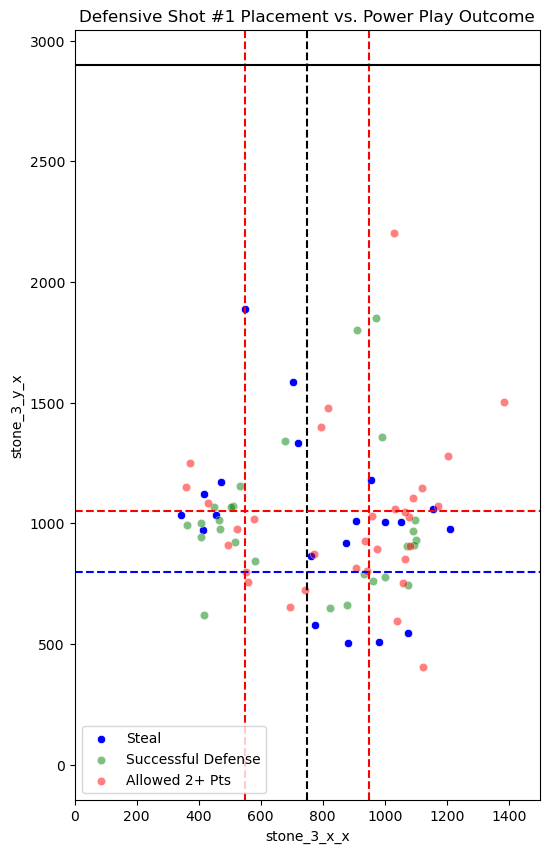

In [165]:
plt.figure(figsize=(6, 10))

sns.scatterplot(
    data=follow_up_shots[follow_up_shots['Defense_Outcome_x']== 'Steal (Best)'],
    x='stone_3_x_x', y='stone_3_y_x', color='blue', label='Steal', marker='o'
)
# Plot Successes (Green/Blue) - The Ideal Zone
sns.scatterplot(
    data=follow_up_shots[follow_up_shots['Defense_Outcome_x'].isin(['Force (Good)'])],
    x='stone_3_x_x', y='stone_3_y_x', color='green', alpha=0.5, label='Successful Defense', marker='o'
)
# Plot Failures (Red) - Where NOT to put the stone
sns.scatterplot(
    data=follow_up_shots[follow_up_shots['Defense_Outcome_x'] == 'Failure (Bad)'],
    x='stone_3_x_x', y='stone_3_y_x', color='red', alpha=0.5, label='Allowed 2+ Pts', marker='o'
)

# Add House Markings for Context (approximate)
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button
plt.axhline(1050, color='red', linestyle='--')  # zones
plt.axvline(950, color='red', linestyle='--')  # zones
plt.axvline(550, color='red', linestyle='--')  # zones
plt.axhline(2900, color='black', linestyle='-') # Hog Line
plt.xlim(0, 1500)
plt.title("Defensive Shot #1 Placement vs. Power Play Outcome")
plt.legend()
#plt.gca().invert_yaxis() # Ensure the house is at the bottom/top correctly based on your Y-axis data
plt.show()

In [166]:
success_rate = follow_up_shots['Defense_Outcome_x'].value_counts(normalize=True)
print('overall outside zone shot 1')
print(len(follow_up_shots))
print(success_rate)

overall outside zone shot 1
81
Defense_Outcome_x
Failure (Bad)    0.419753
Force (Good)     0.333333
Steal (Best)     0.246914
Name: proportion, dtype: float64


In [167]:
zone_again = follow_up_shots[(~follow_up_shots['stone_3_x_x'].between(550, 950)) & (follow_up_shots['stone_3_y_x'].between(750, 1050))]
zone_again_rate = zone_again['Defense_Outcome_x'].value_counts(normalize=True)
print('outside zone again')
print(len(zone_again))
print(zone_again_rate)

outside zone again
28
Defense_Outcome_x
Force (Good)     0.464286
Failure (Bad)    0.321429
Steal (Best)     0.214286
Name: proportion, dtype: float64


In [168]:
outside = follow_up_shots[~follow_up_shots['stone_3_x_x'].between(550, 950)]
outside_rate = outside['Defense_Outcome_x'].value_counts(normalize=True)
print('outside again general')
print(len(outside))
print(outside_rate)

outside again general
57
Defense_Outcome_x
Failure (Bad)    0.403509
Force (Good)     0.368421
Steal (Best)     0.228070
Name: proportion, dtype: float64


In [169]:
center = follow_up_shots[follow_up_shots['stone_3_x_x'].between(550, 950)]
center_rate = center['Defense_Outcome_x'].value_counts(normalize=True)
print('center column')
print(len(center))
print(center_rate)

center column
24
Defense_Outcome_x
Failure (Bad)    0.458333
Steal (Best)     0.291667
Force (Good)     0.250000
Name: proportion, dtype: float64


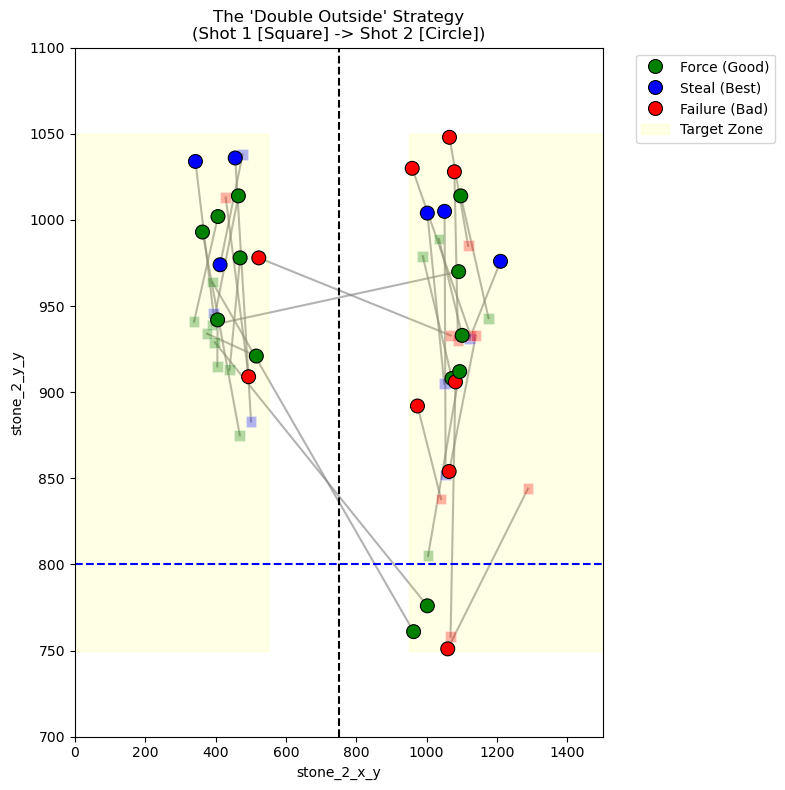

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the "Double Outside" sequence: 
# Shot 1 (Stone 2) AND Shot 2 (Stone 3) are both in the "Outside Edge" zone.
# Zone: x < 550 OR x > 950, AND y between 750 and 1050.
def is_in_zone(df, x_col, y_col):
    return ( (df[x_col] < 550) | (df[x_col] > 950) ) & (df[y_col] > 750) & (df[y_col] < 1050)

double_outside_df = follow_up_shots[
    is_in_zone(follow_up_shots, 'stone_2_x_y', 'stone_2_y_y') & 
    is_in_zone(follow_up_shots, 'stone_3_x_x', 'stone_3_y_x')
].copy()

plt.figure(figsize=(8, 8))

# Define Colors
colors = {'Steal (Best)': 'blue', 'Force (Good)': 'green', 'Failure (Bad)': 'red'}

# 1. Draw Lines connecting Shot 1 -> Shot 2
# This visualizes the "Interaction" (Stacking, Freezing, etc.)
for idx, row in double_outside_df.iterrows():
    outcome = row['Defense_Outcome_x']
    if outcome in colors: # Safety check
        plt.plot([row['stone_2_x_y'], row['stone_3_x_x']], 
                 [row['stone_2_y_y'], row['stone_3_y_x']], 
                 color='gray', alpha=0.6, zorder=1)

# 2. Plot Shot 1 (Stone 2) - Faded Squares
sns.scatterplot(
    data=double_outside_df,
    x='stone_2_x_y', y='stone_2_y_y', hue='Defense_Outcome_x', palette=colors,
    marker='s', s=60, alpha=0.3, legend=False, zorder=2
)

# 3. Plot Shot 2 (Stone 3) - Solid Circles (The "Double Down" move)
sns.scatterplot(
    data=double_outside_df,
    x='stone_3_x_x', y='stone_3_y_x', hue='Defense_Outcome_x', palette=colors,
    marker='o', s=100, edgecolor='black', zorder=3
)

# --- Context & Markings ---
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button Line

# Highlight the Strategic "Outside Zones"
plt.fill_between([0, 550], 750, 1050, color='yellow', alpha=0.1, label='Target Zone')
plt.fill_between([950, 1500], 750, 1050, color='yellow', alpha=0.1)

plt.xlim(0, 1500)
plt.ylim(700, 1100) # Zoom in to the relevant guard/house area
plt.title("The 'Double Outside' Strategy\n(Shot 1 [Square] -> Shot 2 [Circle])")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

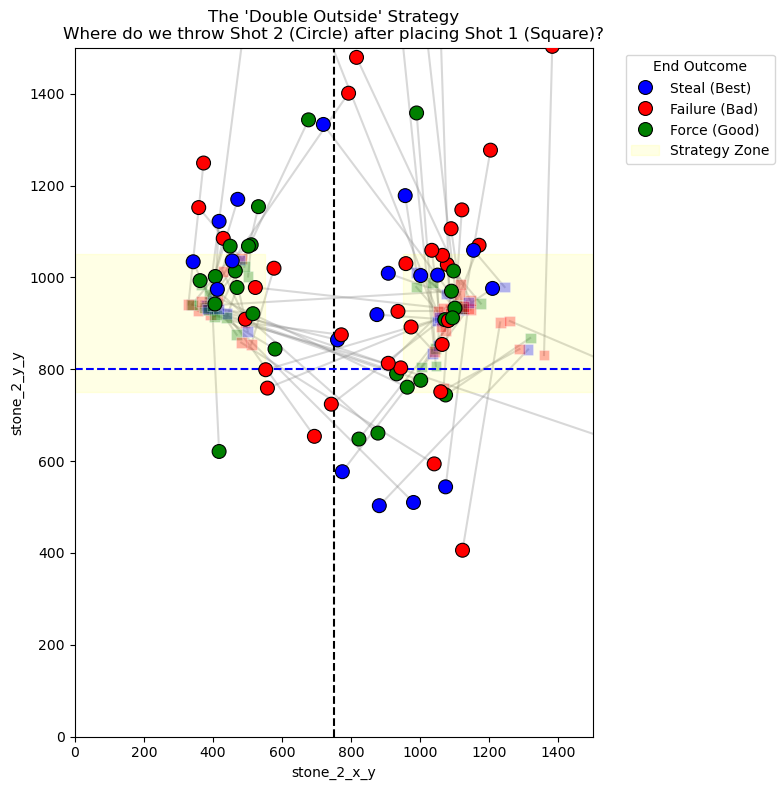

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# We use your 'follow_up_shots' dataframe
# Mapping the 'Ugly' Columns to meaningful variables:
# Shot 1 (Past) = _y suffix (from curious_zones) -> Stone 2 was the active rock
# Shot 2 (Present) = _x suffix (from temp_df) -> Stone 3 is the active rock

# Define the coordinates
# Origin of the strategy (where we put the first one)
shot_1_x = follow_up_shots['stone_2_x_y']
shot_1_y = follow_up_shots['stone_2_y_y']

# Execution of the follow-up (where we put the second one)
shot_2_x = follow_up_shots['stone_3_x_x']
shot_2_y = follow_up_shots['stone_3_y_x']

# Outcome (Result of the End)
outcomes = follow_up_shots['Defense_Outcome_x']

plt.figure(figsize=(8, 8))

# Define Colors
colors = {'Steal (Best)': 'blue', 'Force (Good)': 'green', 'Failure (Bad)': 'red'}

# 1. Draw Lines: Connect the STRATEGY (Shot 1 Location -> Shot 2 Location)
# This shows the "deltas" - are you playing tight to the first stone?
for i in range(len(follow_up_shots)):
    outcome = outcomes.iloc[i]
    if outcome in colors:
        plt.plot([shot_1_x.iloc[i], shot_2_x.iloc[i]], 
                 [shot_1_y.iloc[i], shot_2_y.iloc[i]], 
                 color='gray', alpha=0.3, zorder=1)

# 2. Plot Shot 1 (The Setup) - Faded Squares
# Uses _y columns
sns.scatterplot(
    x=shot_1_x, y=shot_1_y, hue=outcomes, palette=colors,
    marker='s', s=60, alpha=0.3, legend=False, zorder=2
)

# 3. Plot Shot 2 (The Follow-up) - Solid Circles
# Uses _x columns
sns.scatterplot(
    x=shot_2_x, y=shot_2_y, hue=outcomes, palette=colors,
    marker='o', s=100, edgecolor='black', zorder=3
)

# --- Context & Markings ---
plt.axvline(750, color='black', linestyle='--') # Center Line
plt.axhline(800, color='blue', linestyle='--')  # Button

# Highlight the "Outside Edge" Zone (The filter you applied)
plt.fill_between([0, 550], 750, 1050, color='yellow', alpha=0.1, label='Strategy Zone')
plt.fill_between([950, 1500], 750, 1050, color='yellow', alpha=0.1)

plt.xlim(0, 1500)
plt.ylim(0, 1500)
plt.title("The 'Double Outside' Strategy\nWhere do we throw Shot 2 (Circle) after placing Shot 1 (Square)?")
plt.legend(title='End Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()